# HR Employee Attrition — Exploratory Data Analysis

- Dataset: HR-Employee-Attrition.csv
- Rows: 1470
- Columns: 35
- Target: Attrition (Yes / No)

@Yevheniia-Rudenko 26.11.2025

## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv("../2_data_preparation/HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel    

In [6]:
# Summary stats for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [7]:
# Summary for categorical columns
df.describe(include=["object"]).T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


## Quality Check

In [14]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
nunique = df.nunique().sort_values()
nunique

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

- No missing values
- No duplicates
- EmployeeCount, Over18, StandardHours = constant → remove later
- EmployeeNumber = unique ID → drop for modeling

## Target Variable: Attrition

In [11]:
df["Attrition"].value_counts(), df["Attrition"].value_counts(normalize=True).round(3)

(Attrition
 No     1233
 Yes     237
 Name: count, dtype: int64,
 Attrition
 No     0.839
 Yes    0.161
 Name: proportion, dtype: float64)

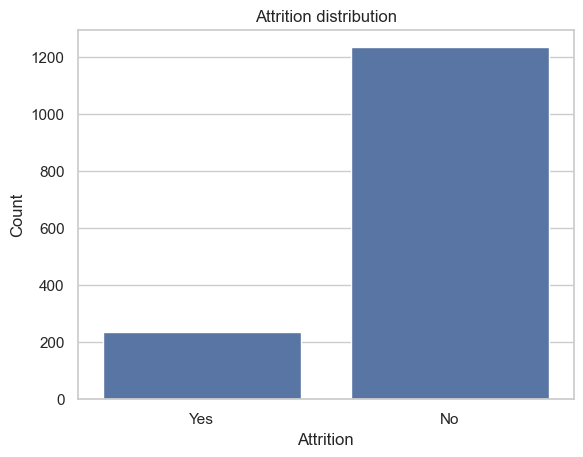

In [12]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="Attrition", ax=ax)
ax.set_title("Attrition distribution")
ax.set_ylabel("Count")
plt.show()

- Attrition Yes = ~16%
- Strong class imbalance → important for modeling

## 	Univariate Analysis

In [15]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

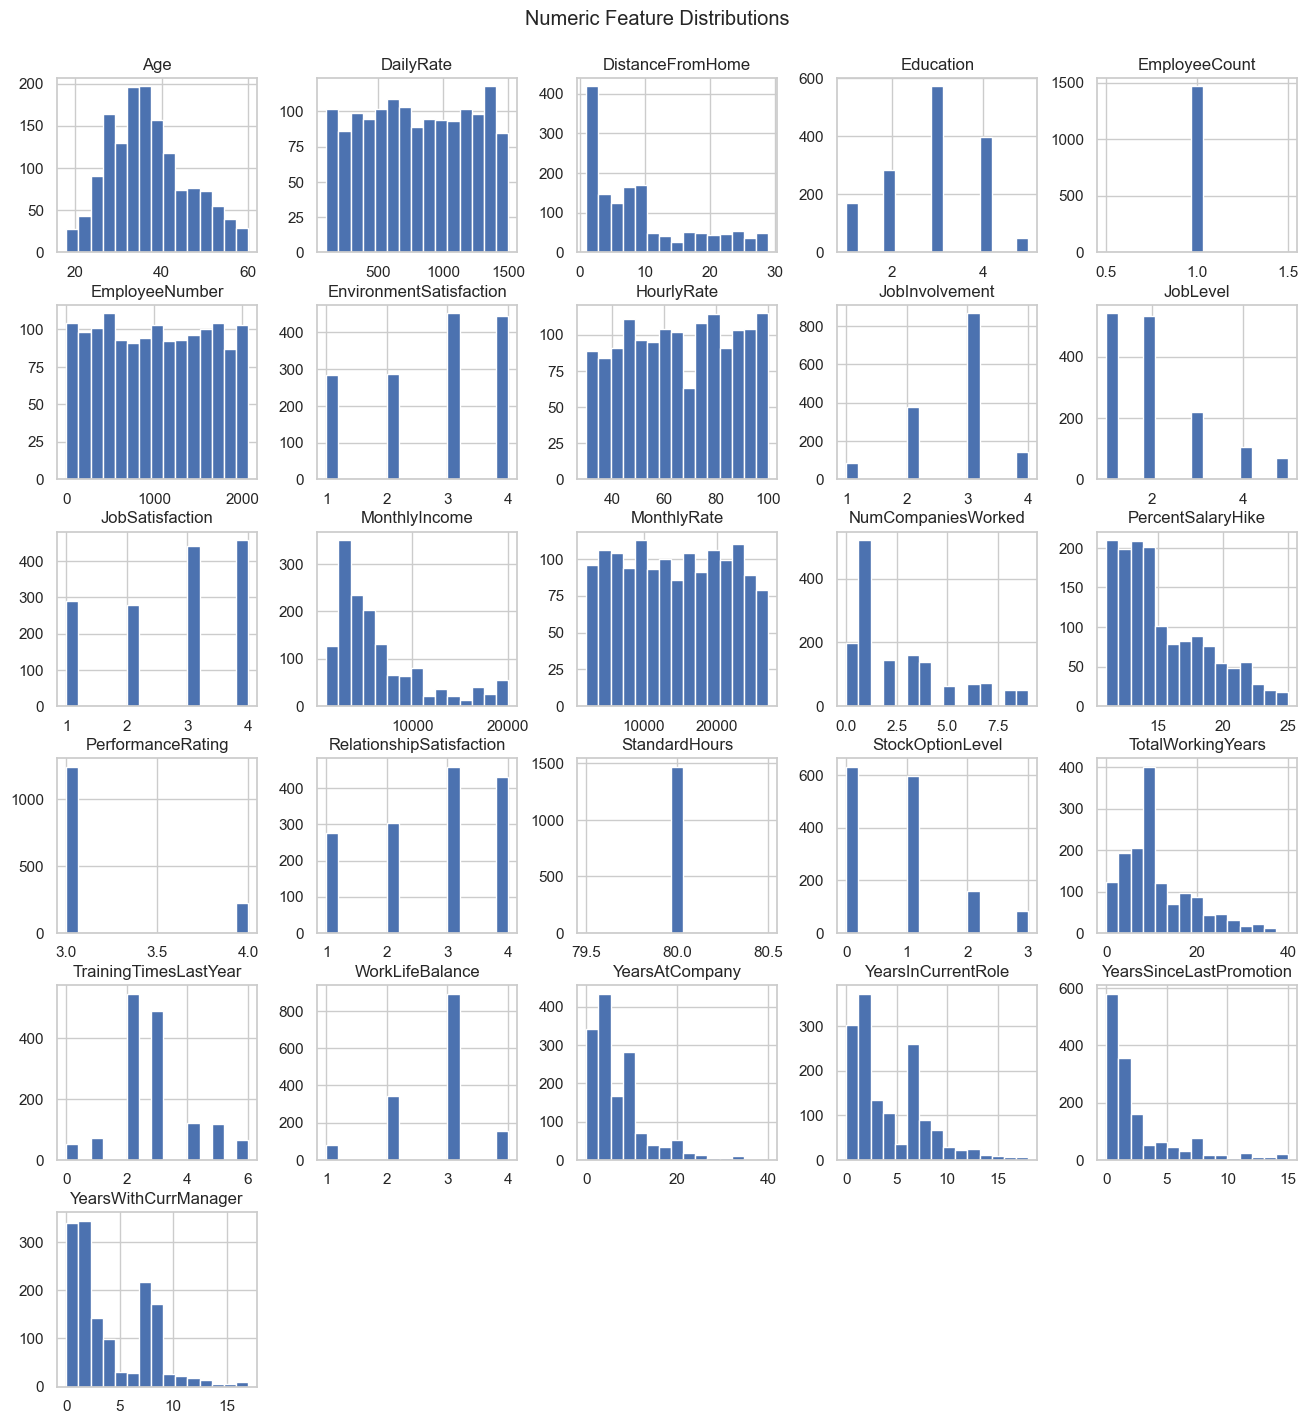

In [23]:
df[numeric_cols].hist(bins=15, figsize=(16, 17))
plt.suptitle("Numeric Feature Distributions", y=0.92)
plt.show()

#### Typical patterns:
- Age moderately left-skewed
- MonthlyIncome strongly right-skewed
- Tenure-related features have long right tails


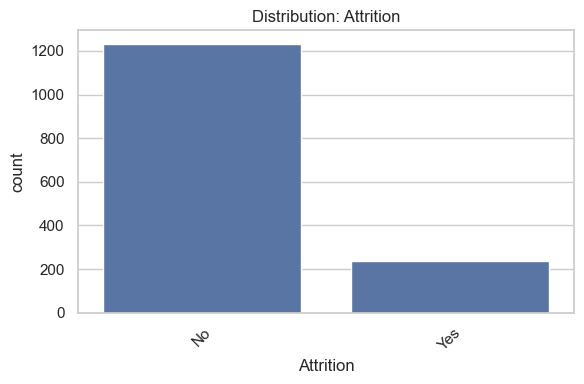

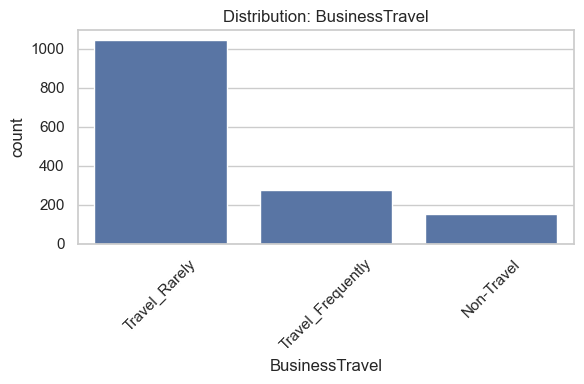

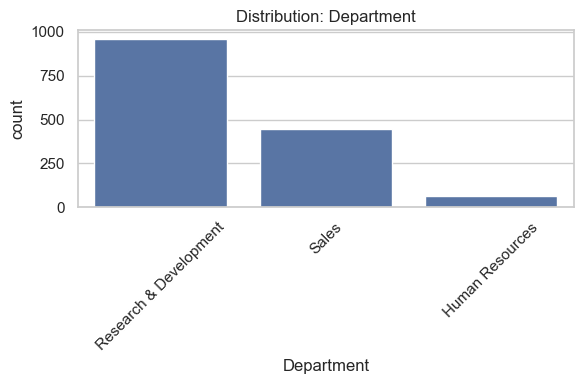

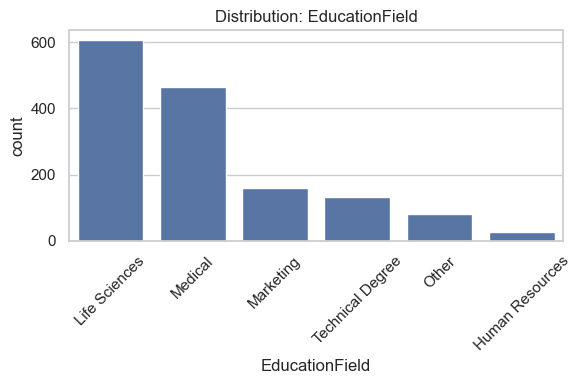

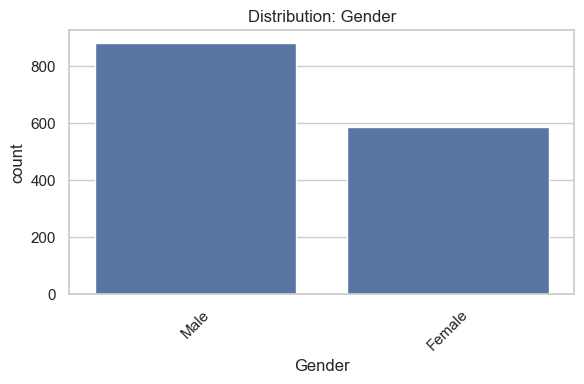

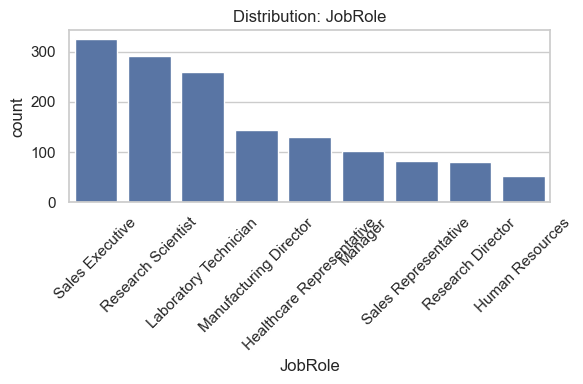

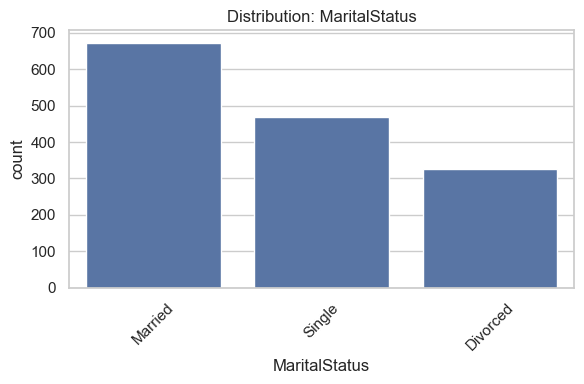

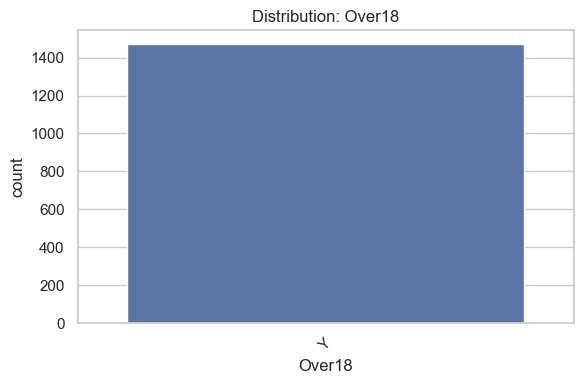

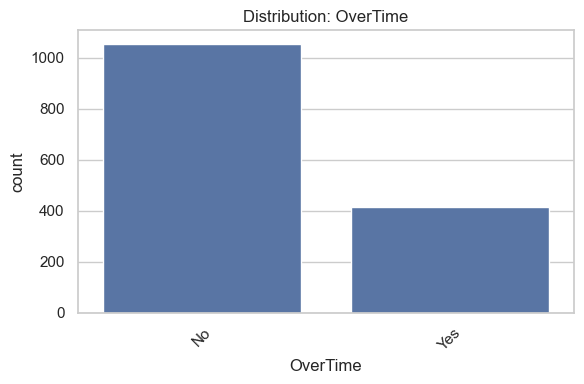

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution: {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Bivariate Analysis: Attrition vs Features

In [ ]:
def plot_attrition(col):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="Attrition", order=df[col].value_counts().index)
    plt.title(f"Attrition by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

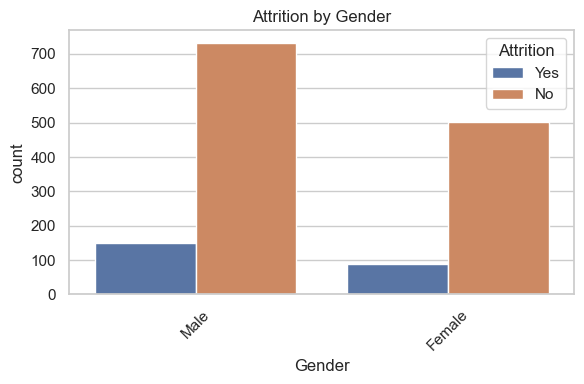

In [ ]:
plot_attrition("Gender")

- Males show slightly higher attrition
- But difference is small

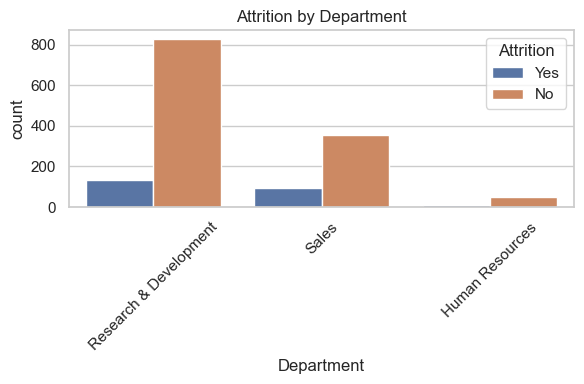

In [31]:
plot_attrition("Department")

- Highest attrition in Sales

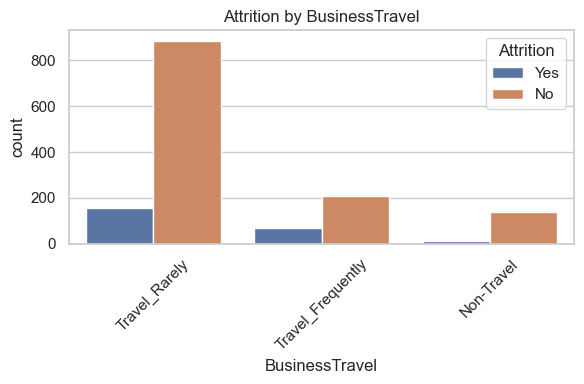

In [32]:
plot_attrition("BusinessTravel")

- Frequent travelers have significantly higher attrition

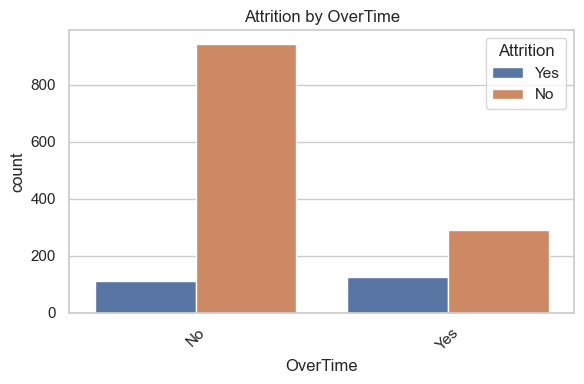

In [33]:
plot_attrition("OverTime")

- OverTime = YES → attrition ~30%
- OverTime = NO → attrition ~10%

## Attrition vs Age & Tenure

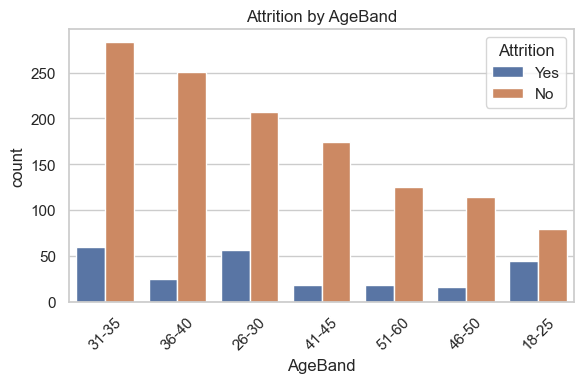

In [ ]:
df["AgeBand"] = pd.cut(
    df["Age"],
    bins=[17, 25, 30, 35, 40, 45, 50, 60],
    labels=["18-25", "26-30", "31-35", "36-40", "41-45", "46-50", "51-60"],
)

plot_attrition("AgeBand")

- Young employees (18–25) have the highest attrition (~35%)
- Older employees show much lower attrition

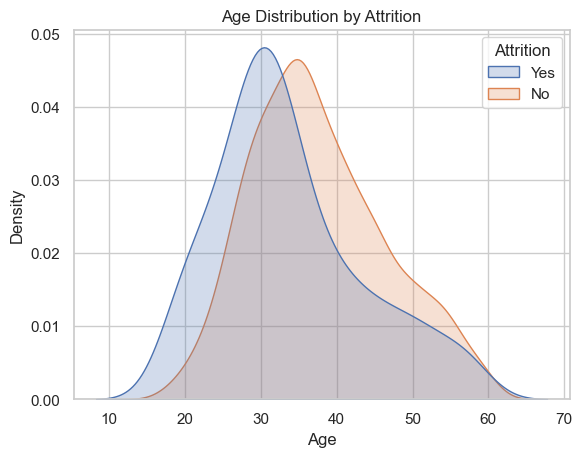

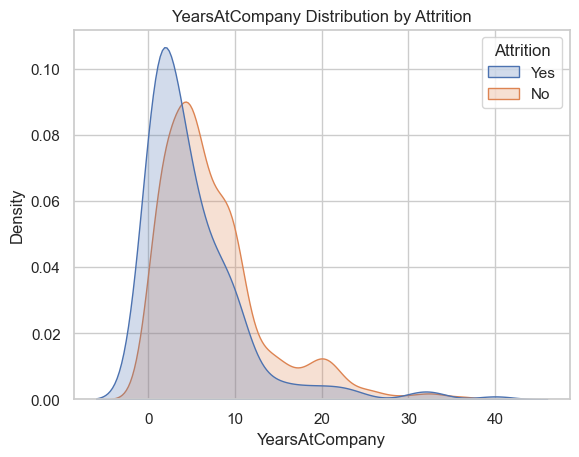

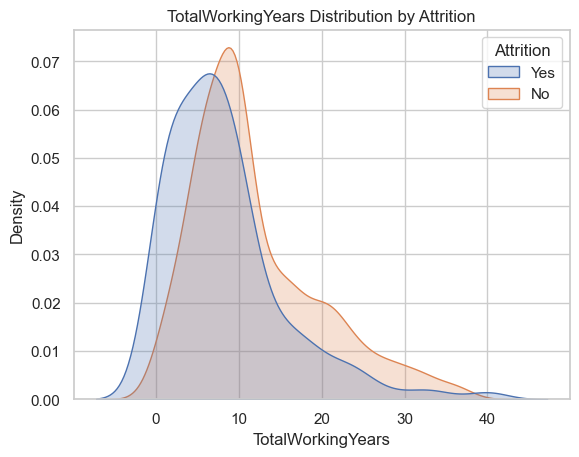

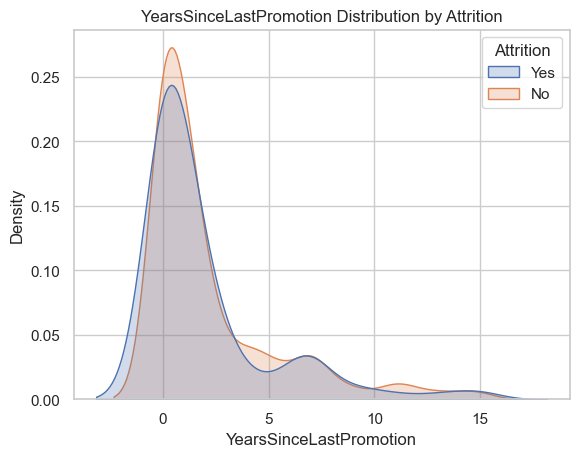

In [35]:
for col in ["Age", "YearsAtCompany", "TotalWorkingYears", "YearsSinceLastPromotion"]:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue="Attrition", fill=True, common_norm=False)
    plt.title(f"{col} Distribution by Attrition")
    plt.show()

## Correlation Analysis

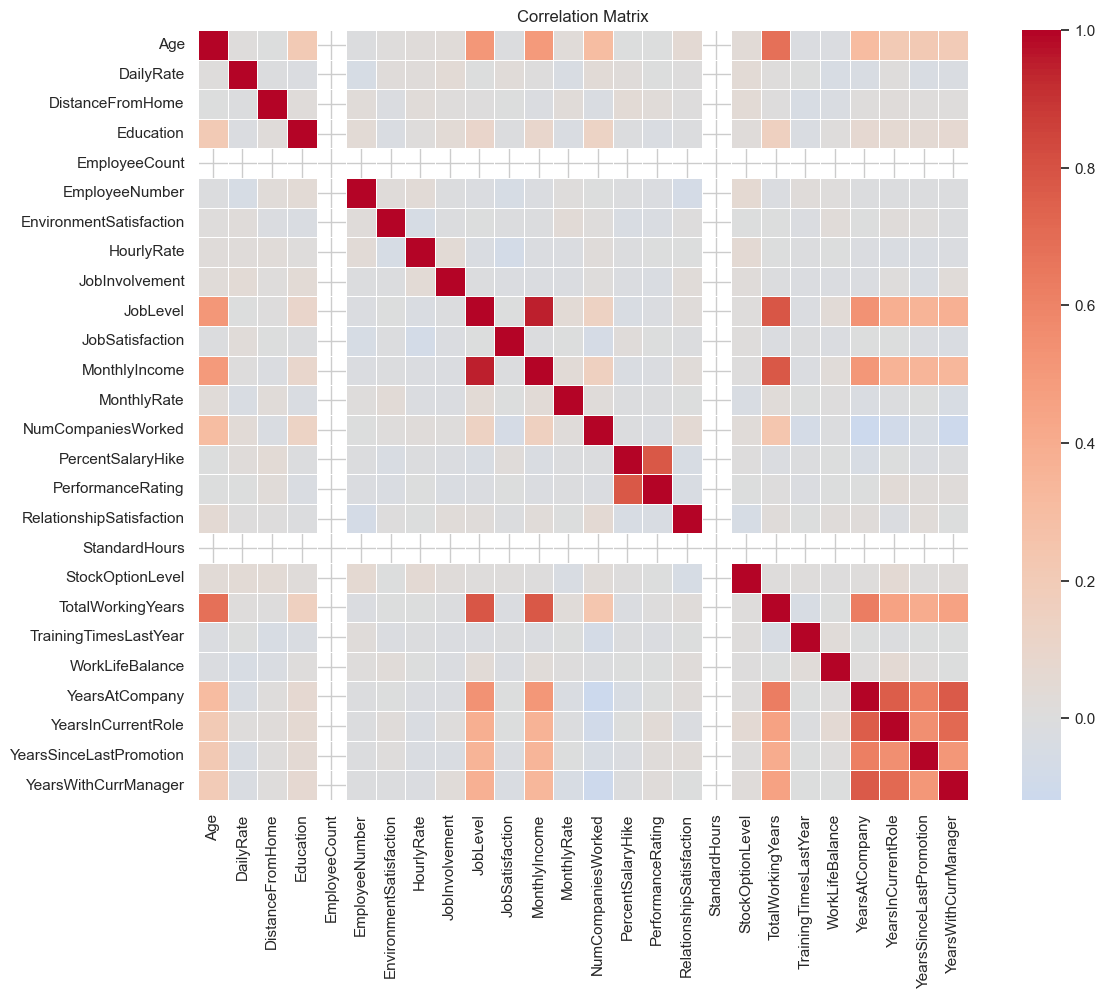

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

- Age correlates strongly with TotalWorkingYears
- Tenure features tend to cluster together
- No extreme multicollinearity issues except tenure-related pairs

## Key Insights Summary

1. Strongest predictors of attrition
- OverTime (Yes → 3× higher attrition)
- BusinessTravel (Frequent)
- JobRole (Sales Representative highest)
- Age (youngest employees leave the most)
- Short tenure / few years at company

2. Dataset observations
- No missing values
- No duplicates
- Several constant columns → drop
- Strong imbalance: only 16% attrition

3. HR insights
- Overwork and frequent travel significantly increase risk
- Young employees and early-tenure employees require retention strategies
- Sales and HR roles have above-average churn